In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

# Reading chains

In [3]:
### 2PT ONLY
# analytic covariance, no compression
s_2pt = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-run/des-y3-2pt.txt', to_mcsamples=True, blind=False)
# simulation based covariance, no compression
s_2pt_sim = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-run/des-y3-2pt-500simcov.txt', to_mcsamples=True, blind=False)
# simulation based covariance for compression and likelihood
s_2pt_simsim = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-moped-run/des-y3-2pt-500simcov-500simcov-compress.txt', to_mcsamples=True, blind=False)
# analytic covariance for compression, simulation based covariance for likelihood
s_2pt_moped= utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-moped-run/des-y3-2pt-500simcov.txt', to_mcsamples=True, blind=False)

### JOINT
s_joint = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=False)
s_joint_auto = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-auto.txt', to_mcsamples=True, blind=False)
#s_joint_auto_334_344 = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-auto-334-344.txt', to_mcsamples=True, blind=False)

### BARYON
#s_baryon = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-baryon-run/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=False)

### wCDM
#s_2pt_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-moped-run/des-y3-2pt-400simcov-wCDM.txt', to_mcsamples=True, blind=False)
#s_joint_wCDM = utils.read_cosmosis_mcmc_des_chain('../output/test-desy3c-joint-2pt-moped-run/des-y3-2pt-map3-all-wCDM.txt', to_mcsamples=True, blind=False)

### Comparison of theory vs cosmogrid
#s_joint_cosmogrid = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run/des-y3-2pt-map3-all.txt', to_mcsamples=True, blind=False)
#s_2pt_cosmogrid = utils.read_cosmosis_mcmc_des_chain('../output/test-cosmogridc-joint-2pt-moped-run/des-y3-2pt-400simcov.txt', to_mcsamples=True, blind=False)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


## Plotting
### Validation of 2pt compression

<Figure size 600x600 with 0 Axes>

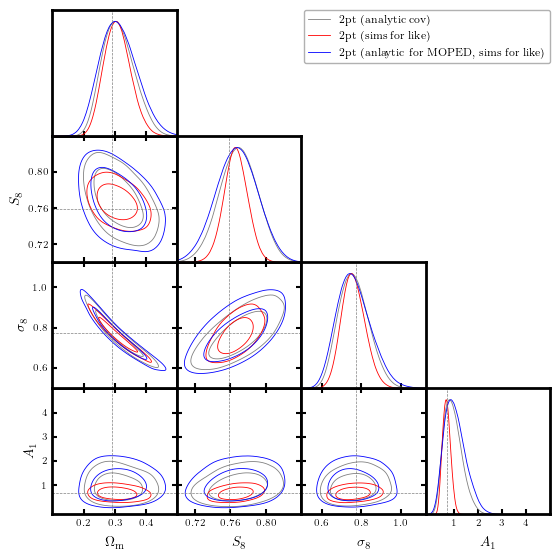

In [4]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt, s_2pt_sim, s_2pt_moped], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt (analytic cov)', '2pt (sims for like)',  '2pt (anlaytic for MOPED, sims for like)'], legend_loc='upper right', 
    contour_colors=['gray', 'red', 'blue'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

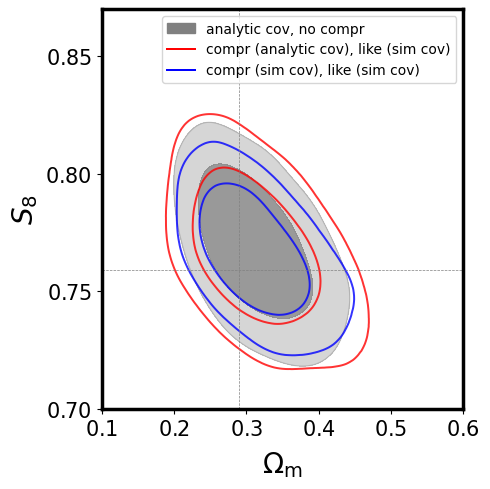

In [9]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = True
g.plot_2d([s_2pt, s_2pt_moped, s_2pt_simsim], 'om', 's8', filled=[True, False, False, False], \
    colors=['gray', 'red', 'blue'], alphas=[0.8, 0.8, 0.8, 0.8])
g.add_legend(['analytic cov, no compr', \
    'compr (analytic cov), like (sim cov)', \
    'compr (sim cov), like (sim cov)'],
    legend_loc='upper right', fontsize=10)
g.add_x_marker(0.29)
g.add_y_marker(0.759)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
ax = g.get_axes()  # Get the main axes object
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
g.export('../plots/contour2d_test_2pt_moped_cov_choice_500simcov_16Dec.pdf')

<>:4: SyntaxWarning: invalid escape sequence '\&'
<>:4: SyntaxWarning: invalid escape sequence '\&'
/var/folders/1m/ncv9_zyd2jx24czdhnwkm_3w0000gn/T/ipykernel_5589/2883845844.py:4: SyntaxWarning: invalid escape sequence '\&'
  g.add_legend(['2pt (analytic cov)', '2pt (sims for compr \& like)',  '2pt (anlaytic for MOPED, sims for like)'], legend_loc='upper right')


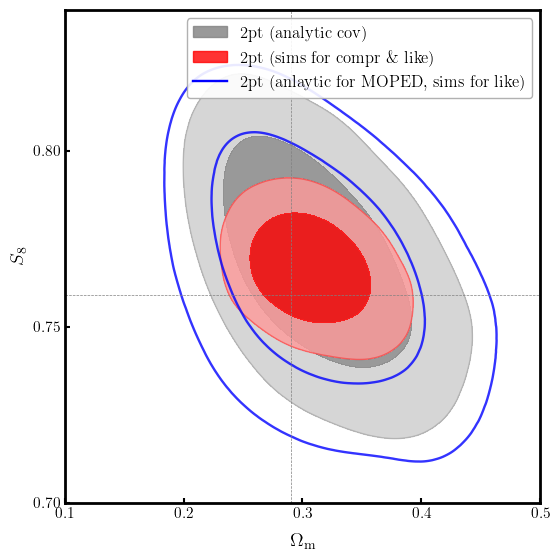

In [6]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.plot_2d([s_2pt, s_2pt_simsim, s_2pt_moped], 'om', 's8', filled=[True, True, False], \
    colors=['gray', 'red', 'blue'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['2pt (analytic cov)', '2pt (sims for compr \& like)',  '2pt (anlaytic for MOPED, sims for like)'], legend_loc='upper right')
g.add_x_marker(0.29)
g.add_y_marker(0.759)

### Improvement with map3

<Figure size 600x600 with 0 Axes>

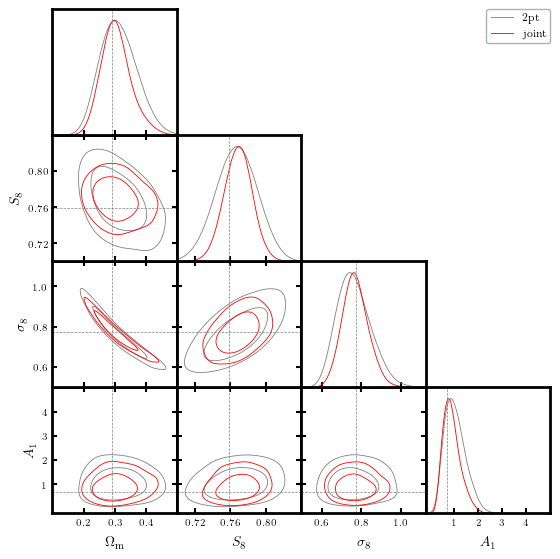

In [7]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt_moped, s_joint], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['2pt', 'joint'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

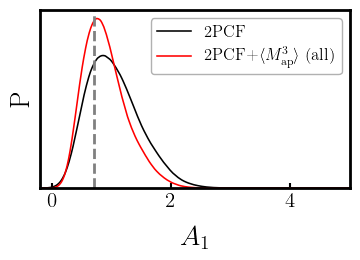

In [13]:
g = plots.get_single_plotter(width_inch=4)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_1d([s_2pt_moped, s_joint], 'a1', normalized=True)
g.add_legend(['2PCF', r'2PCF+$\langle M_{\rm ap}^3\rangle$ (all)'])
ax = g.get_axes()
ax.axvline(0.7, color='gray', ls='--')
g.export('../plots/post1d_test_AIA_2pt_map3.pdf')
plt.show()

In [9]:
fom_2pt = utils.FoM_from_samples_names(s_2pt_moped, ['om', 's8'])
fom_joint = utils.FoM_from_samples_names(s_joint, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(s_joint_auto, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(s_joint_auto_334_344, ['om', 's8'])

print(fom_2pt, fom_joint, fom_joint_auto, fom_joint_auto_334_344)
print(fom_joint/fom_2pt, fom_joint_auto/fom_2pt, fom_joint_auto_334_344/fom_2pt)

838.9208657595022 1346.339350584713 1016.8907368050677 1144.8441915870183
1.6048466613901995 1.2121414287203878 1.3646629119786569


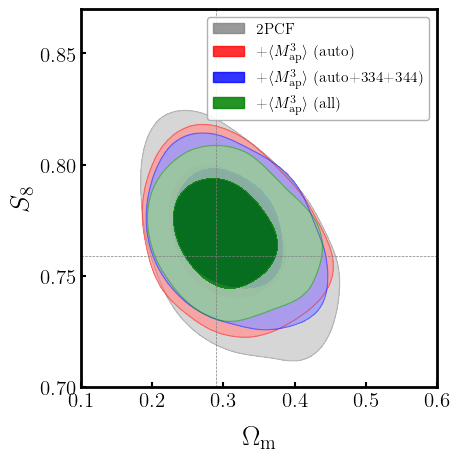

In [50]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([s_2pt_moped, s_joint_auto, s_joint_auto_334_344, s_joint], 'om', 's8', filled=True, 
    colors=['gray', 'red', 'blue', 'green'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['2PCF', \
    r'+$\langle M_{\rm ap}^3\rangle$ (auto)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (auto+334+344)', 
    r'+$\langle M_{\rm ap}^3\rangle$ (all)'],
    legend_loc='upper right', fontsize=11)
g.add_x_marker(0.29)
g.add_y_marker(0.759)
g.get_axes().set_xlim(0.1, 0.6)
g.get_axes().set_ylim(0.7, 0.87)
g.export('../plots/contour2d_test_2pt_map3.pdf')

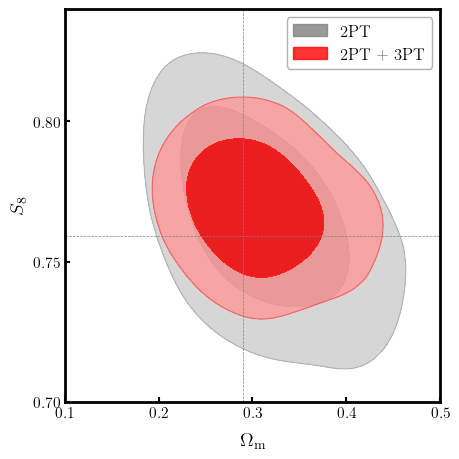

In [15]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([s_2pt_moped, s_joint], 'om', 's8', filled=True, 
    colors=['gray', 'red'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['2PT', '2PT + 3PT'], legend_loc='upper right')
g.add_x_marker(0.29)
g.add_y_marker(0.759)

In [51]:
import pandas as pd

fom_2pt = utils.FoM_from_samples_names(s_2pt_moped, ['om', 's8'])
fom_joint_auto = utils.FoM_from_samples_names(s_joint_auto, ['om', 's8'])
fom_joint_auto_334_344 = utils.FoM_from_samples_names(s_joint_auto_334_344, ['om', 's8'])
fom_joint_all = utils.FoM_from_samples_names(s_joint, ['om', 's8'])

data = {'Analysis': ['2pt only', '2pt+map3 (auto only)', '2pt+map3 (auto+334+344)', '2pt+map3 (all)'],
    'FoM': [fom_2pt, fom_joint_auto, fom_joint_auto_334_344, fom_joint_all],
    'Ratio to 2pt': [1, fom_joint_auto/fom_2pt, fom_joint_auto_334_344/fom_2pt, fom_joint_all/fom_2pt]}

df = pd.DataFrame(data)
df

,Analysis,FoM,Ratio to 2pt
0,2pt only,838.920866,1.000000
1,2pt+map3 (auto only),1016.890737,1.212141
2,2pt+map3 (auto+334+344),1144.844192,1.364663
3,2pt+map3 (all),1346.339351,1.604847


### wCDM

<Figure size 600x600 with 0 Axes>

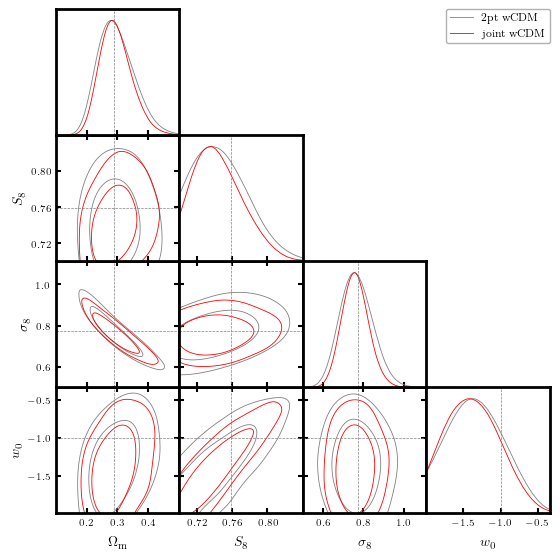

In [9]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt_wCDM, s_joint_wCDM], ['om', 's8', 'sig8', 'w0'], filled=False, \
    legend_labels=['2pt wCDM', 'joint wCDM'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'w0':-1.0})
plt.show()

Text(0.5, 1.02, '$w$CDM')

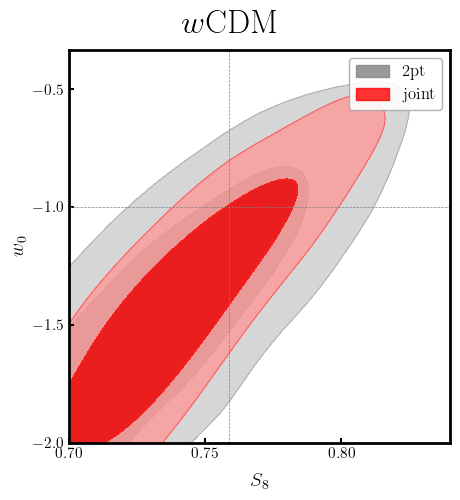

In [10]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.plot_2d([s_2pt_wCDM, s_joint_wCDM], 's8', 'w0', filled=True, 
    colors=['gray', 'red', 'blue', 'green'], alphas=[0.8, 0.8, 0.8])
g.add_legend([r'2pt', r'joint'], legend_loc='upper right')
g.add_x_marker(0.759)
g.add_y_marker(-1.0)
plt.suptitle(r'$w$CDM', y=1.02)

#### Baryon effect

<Figure size 600x600 with 0 Axes>

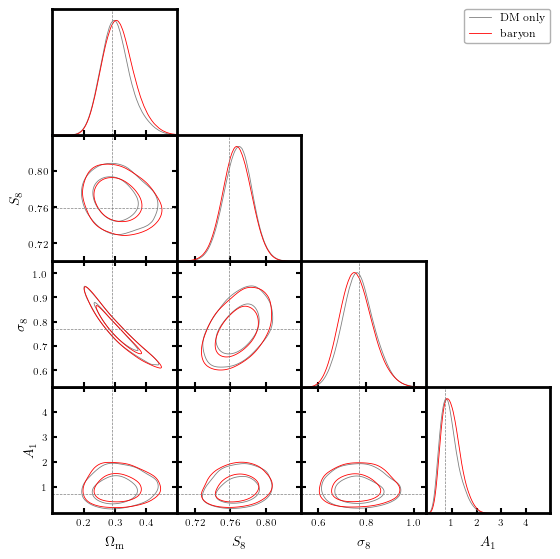

In [52]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_joint, s_baryon], ['om', 's8', 'sig8', 'a1'], filled=False, \
    legend_labels=['DM only', 'baryon'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.29, 's8':0.759, 'sig8': 0.772, 'a1':0.7})
plt.show()

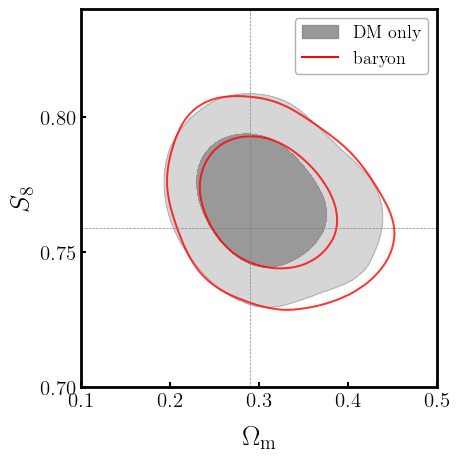

In [57]:
g = plots.get_single_plotter(ratio=1, width_inch=5)
g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 15
g.settings.figure_legend_frame = False
g.plot_2d([s_joint, s_baryon], 'om', 's8', filled=[True, False], 
    colors=['gray', 'red', 'blue', 'green'], alphas=[0.8, 0.8, 0.8])
g.add_legend(['DM only', 'baryon'],
    legend_loc='upper right', fontsize=13)
g.add_x_marker(0.29)
g.add_y_marker(0.759)
# g.get_axes().set_xlim(0.1, 0.5)
# g.get_axes().set_ylim(0.7, 0.82)
g.export('../plots/contour2d_test_baryon_2pt_map3.pdf')

### VS CosmoGrid

<Figure size 600x600 with 0 Axes>

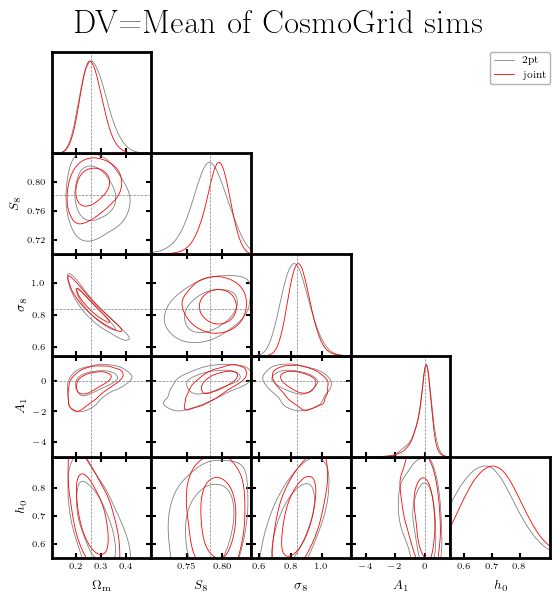

In [13]:
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([s_2pt_cosmogrid, s_joint_cosmogrid], ['om', 's8', 'sig8', 'a1', 'h0'], filled=False, \
    legend_labels=['2pt', 'joint'], legend_loc='upper right', 
    contour_colors=['gray', 'red'],
    markers={'om': 0.26, 's8':0.782, 'sig8': 0.84, 'a1':0.0})
plt.suptitle('DV=Mean of CosmoGrid sims', y=1.02)
plt.show()

cosmogrid predictions

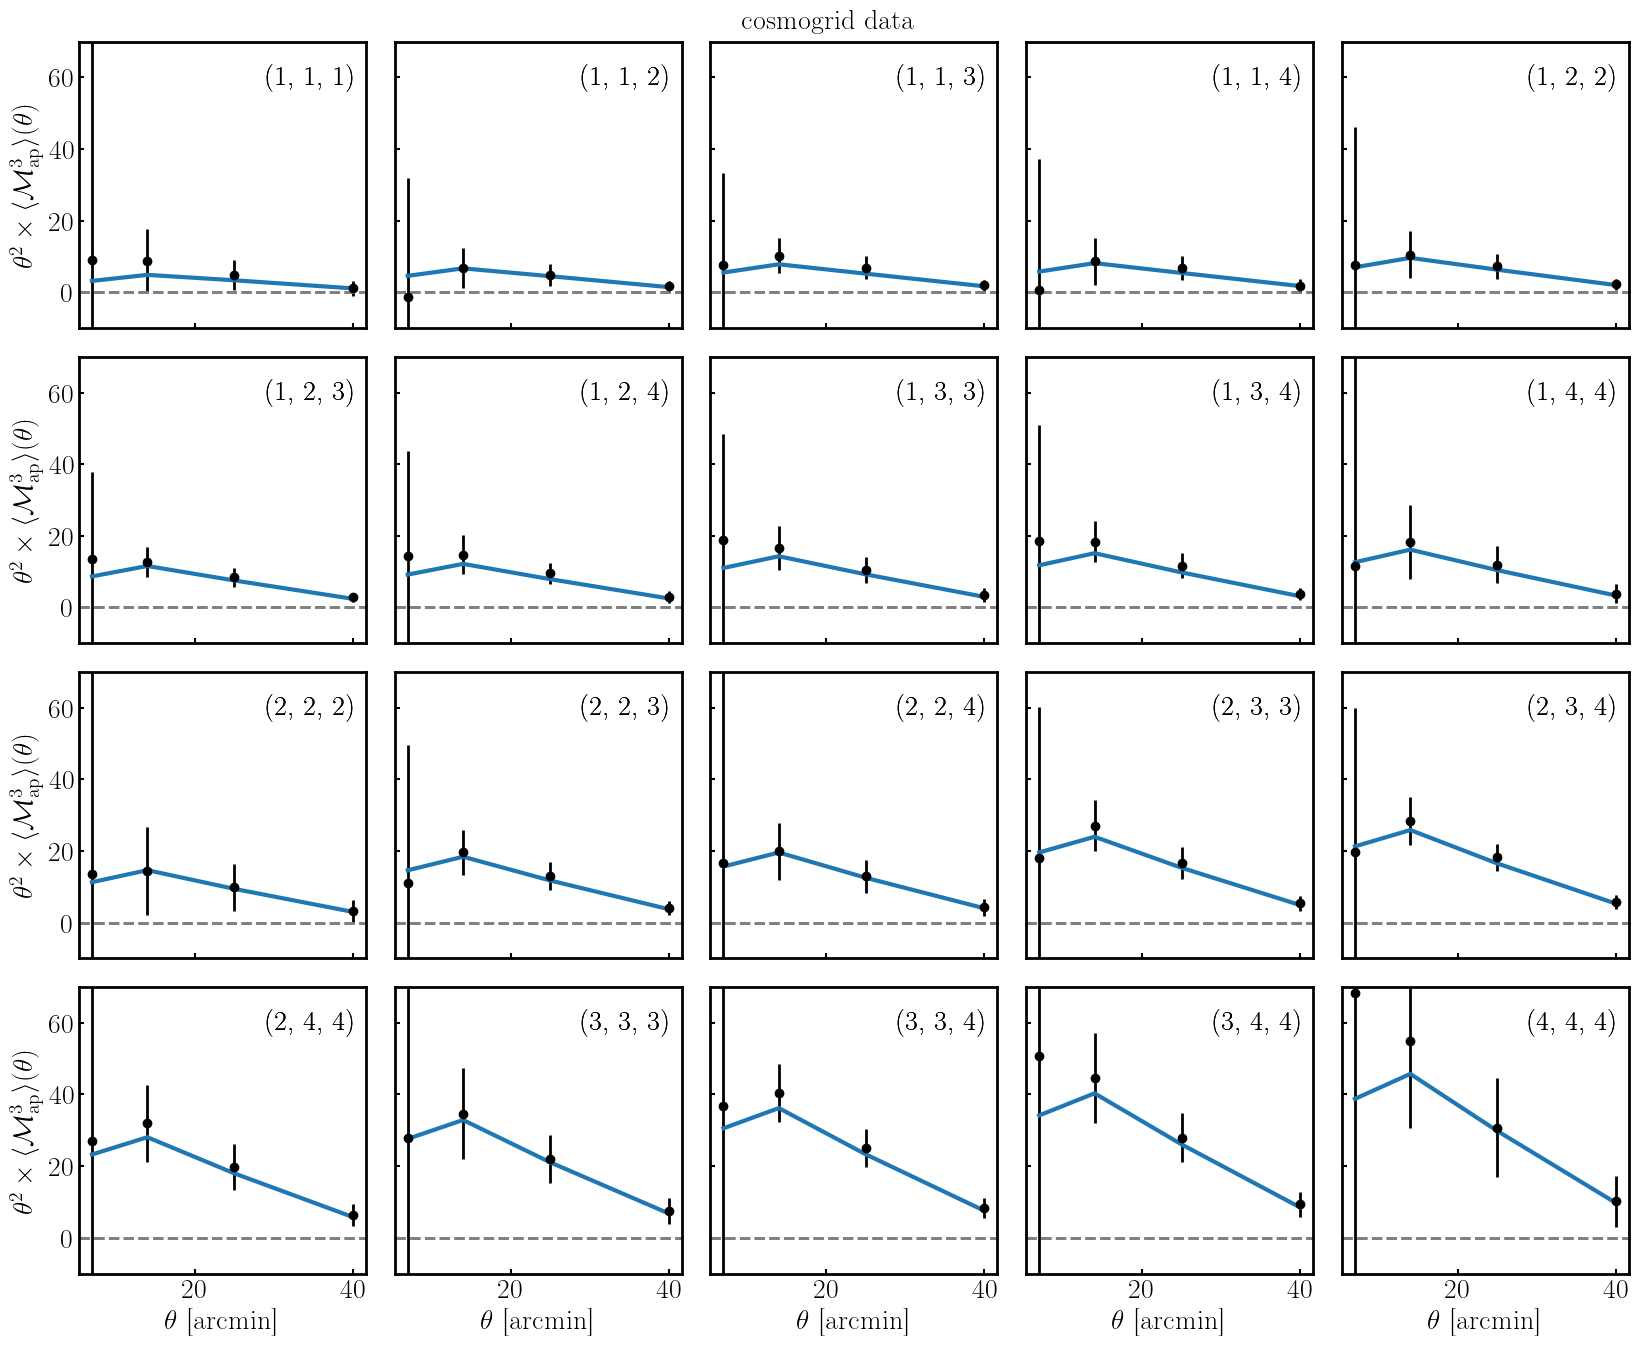

In [3]:
thpt = threepoint.ThreePointDataClass.from_fits('../data/dv/meas_map3-ave-cosmogrid.fits')
line_args = dict(color='k')
fig, axes = thpt.plot2d(4, 5, figsize=(20, 16), t_sidx=2, rescale_ebar=1, title='cosmogrid data', **line_args)
thpt_bf = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_temp_fastnc.fits')
# thpt_bf = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_temp.fits')
line_args = dict(color='C0', lw=3)
fig, axes = thpt_bf.plot2d(4, 5, t_sidx=2, figaxes=(fig, axes), ebar=False, **line_args)

# t = np.array([7.0,14.0,25.0,40.0])
# for i_noise in range(1):
#     ave = np.loadtxt('../data/ave_2pcf_map3_n280_noise{}.dat'.format(i_noise))[400:]
#     ave = ave.reshape((20, 4))
#     for i in range(4):
#         for j in range(5):
#             axes[i,j].plot(t, -t**2*ave[i*4+j, :]/1e-8, color='C1', lw=3, ls='--')


In [4]:
ave.shape

NameError: name 'ave' is not defined

In [5]:
s1= thpt.get_signal()
s2= thpt_bf.get_signal()
e = thpt.get_std()

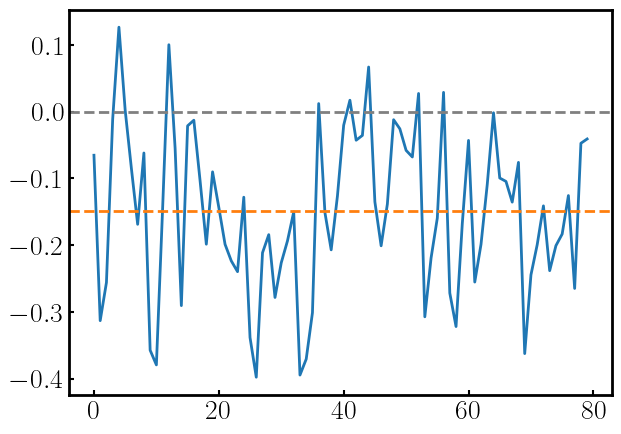

In [7]:
y = (s2-s1)/e
# y = y[3::4]
plt.plot(y)
_ = np.mean(y)
plt.axhline(_, color='C1', ls='--')
plt.axhline(0, color='gray', ls='--')
plt.show()

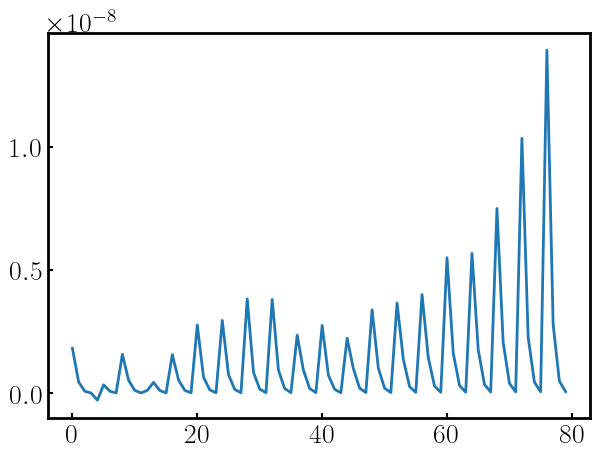

In [10]:
plt.plot(s1)
plt.show()

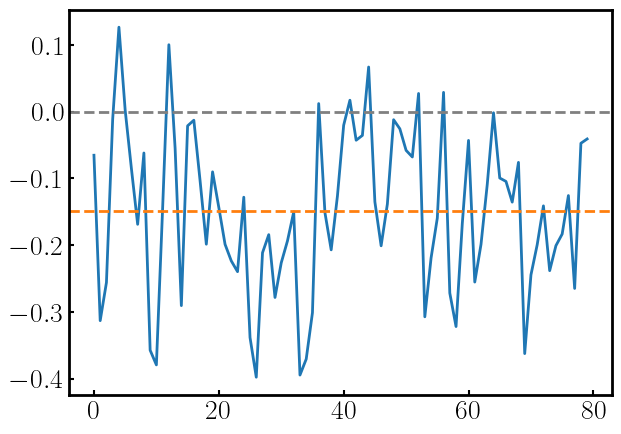

In [11]:
plt.plot((s2-s1)/e)
_ = np.mean((s2-s1)/e)
plt.axhline(_, color='C1', ls='--')
plt.axhline(0, color='gray', ls='--')
plt.show()

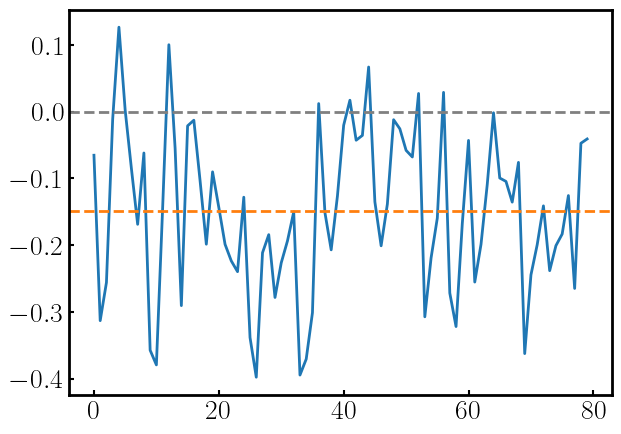

In [12]:
plt.plot((s2-s1)/e)
_ = np.mean((s2-s1)/e)
plt.axhline(_, color='C1', ls='--')
plt.axhline(0, color='gray', ls='--')
plt.show()

In [13]:
diff

NameError: name 'diff' is not defined